<img src="https://www.pucsp.br/sites/default/files/download/brasao-PUCSP-assinatura-principal-RGB.png" style="float:right;" width="150px">

# Ciências da Computação [》](https://www.pucsp.br/graduacao/ciencia-da-computacao)

## Inteligência Artificial

IA ML (Machine Learning, Aprendizagem de Máquina)

**Objetivo deste LAB explorar os modelos de Regressão Linear e Regressão Logística com Scikit-Learn em Python, sobre os dados de "Happines por idade e país"**

- Regressão Linear: <br>
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

- Regressão Logistica: <br>
https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

# LAB: Felicidade por Idade e por País

> ### Informações da atividade
>
> - **Formato:** projeto em **dupla** (*pair programming*).
> - **Prazo:** até o **final do dia** da aula LAB.
> - **Publicação:** GitHub + link no MS Teams.

**Dupla**

| | Nome | Usuário no GitHub |
| --- | --- | --- |
| Integrante 1 | **Nicolas Mariano da Silva** | **niickmds** |
| Integrante 2 | **Pedro Henrique Isamu Fagunes de Souza Tsukahara Yoshissaro** | **knutzin** |

**Checklist de entrega**

- [ ] Rodar **Kernel → Restart & Run All** em um ambiente com internet na primeira execução (a API do Banco Mundial será consultada e salva em cache).
- [ ] Salvar o notebook **com as saídas**.
- [x] Repositório preparado com `README.md`, `requirements.txt`, `lab_helpers.py`, dados locais do OWID e este notebook.
- [ ] Garantir commits dos dois integrantes.
- [ ] Enviar o link do repositório no MS Teams.

## 1. Contexto

Neste laboratório vamos testar uma das afirmações mais debatidas na pesquisa sobre felicidade: a de que a satisfação com a vida segue uma **curva em U** ao longo da idade, e de que o formato dessa curva depende de onde a pessoa vive. Vocês vão construir o pipeline completo, dos dados brutos ao modelo ajustado, usando **Python, scikit-learn e Seaborn**.

Pesquisadores medem bem-estar com a **escada de Cantril** (*Cantril ladder*): a pessoa avalia sua vida atual de 0 (pior vida possível) a 10 (melhor vida possível). O **Gallup World Poll** faz essa pergunta em amostras nacionalmente representativas em mais de 140 países, e o **World Happiness Report (WHR)** publica as médias nacionais, em geral como médias móveis de três anos.

Duas histórias concorrentes sobre a idade aparecem nesses dados:

- **A curva em U clássica.** Estudos do Reino Unido e de outros países de renda alta mostram a felicidade caindo a partir dos 20 anos, até os 40 ou início dos 50, e depois subindo até se estabilizar por volta dos 70. As explicações incluem a pressão da meia-idade (emprego, filhos, cuidado com pais idosos) e a adaptação e as expectativas menores na velhice.
- **Um alvo em movimento.** O capítulo sobre idade do WHR 2024 mostra que a felicidade dos jovens (15 a 24 anos) na América do Norte caiu bastante desde 2006-2010, e hoje eles estão menos felizes que os mais velhos. Na Europa Central e Oriental aconteceu o oposto: a felicidade subiu em todas as idades. Quem nasceu depois de 1980 também relata avaliações de vida menores que as coortes anteriores.

*The Happiness Curve* é a versão popular, em formato de livro, da primeira história. O trabalho de vocês é ver quanto de cada história sobrevive aos dados, e perceber o que renda, população e área do país mudam nesse quadro.

**Por que isso é um bom exercício de ML.** A pergunta se traduz em duas tarefas supervisionadas clássicas. Prever uma nota (0 a 10) a partir de idade e características do país é **regressão**. Prever se um grupo está acima ou abaixo de um limiar de felicidade é **classificação**. A curva em U também traz uma lição embutida: uma reta é o modelo errado para a idade, e vocês devem ser capazes de mostrar por quê.

## 2. Objetivos de aprendizagem e pré-requisitos

Ao final do laboratório, seremos capazes de construir, avaliar e explicar dois modelos do scikit-learn sobre um conjunto de dados combinado de várias fontes, dizendo com honestidade o que eles mostram e o que não mostram. Organize o tempo de laboratório, mais as leituras. Como o projeto é em dupla, a divisão de trabalho sugerida está abaixo.

Vocês serão capazes de:

- Combinar dados de pesquisa com indicadores do Banco Mundial usando uma chave de país, e auditar o *join* para achar países sem correspondência.
- Criar atributos (*features*) a partir de grandezas assimétricas (log do PIB per capita, log da população, log da área) e explicar o motivo.
- Ajustar uma regressão linear e visualizá-la com Seaborn, mostrando que um termo quadrático na idade supera a reta.
- Transformar uma variável numérica em rótulo binário, ajustar uma regressão logística e embrulhá-la em uma função reutilizável que devolve P(feliz) para uma idade e um país.
- Avaliar com uma divisão **agrupada por país**, para que o modelo seja testado em países que nunca viu.

**Pré-requisitos:** noções de pandas, o padrão `fit` / `predict` do scikit-learn e um laboratório anterior sobre divisão treino/teste.

In [61]:
# Instalação (rode uma vez, se necessário). Remova o "#" da linha abaixo:
# !pip install pandas numpy scikit-learn seaborn matplotlib requests openpyxl country_converter

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
RANDOM_STATE = 42   # semente fixa: seus resultados precisam ser reproduzíveis

## 3. Passo 0: leia antes de programar

Leiam as quatro fontes e escrevam **uma frase por fonte** respondendo à pergunta da tabela. Vocês vão reaproveitar essas frases na discussão final.

| Fonte | O que extrair |
| --- | --- |
| [Gallup: World Happiness Report](https://www.gallup.com/analytics/349487/world-happiness-report.aspx) | Qual é exatamente a pergunta da escada de Cantril? Quem é entrevistado, e por que as notas nacionais são médias de três anos? |
| [WEF: At what age does happiness peak?](https://www.weforum.org/stories/wellbeing-and-mental-health/at-what-age-does-happiness-peak/) | Onde fica o mínimo da curva em U, e em quais dados de países de renda alta a afirmação se apoia? Quais mecanismos são propostos? |
| [World Happiness Report 2024: Happiness and age (resumo)](https://www.worldhappiness.report/ed/2024/happiness-and-age-summary/) | Quais regiões quebram o padrão em U? O que é diferente em quem nasceu depois de 1980? Quais faixas etárias o relatório usa? |
| [The Happiness Curve (Macmillan)](https://us.macmillan.com/books/9781427292988/thehappinesscurve/) | Qual é o argumento central do livro, e vocês esperariam que ele valesse para um país de renda baixa? |

Dois detalhes que vocês vão usar depois. O capítulo de idade do WHR 2024 usa **quatro faixas etárias** (menos de 30, 30-44, 45-59 e 60+), então o conjunto de dados de vocês também terá quatro. E ele compara as médias de 2021-2023 com uma base de 2006-2010, então **sempre registrem a que anos os seus dados se referem**. Os números por faixa etária que vocês vão baixar na Parte 1 vêm do [Our World in Data](https://ourworldindata.org/grapher/cantril-ladder-age-groups?tab=table), que republica os resultados do WHR 2024; deem uma olhada na visualização em tabela agora.

**Minhas notas de leitura**

1. **Gallup:** a escada de Cantril pede que a pessoa avalie a vida atual de 0 (pior vida possível) a 10 (melhor vida possível); o Gallup World Poll usa amostras nacionalmente representativas e o WHR usa médias de três anos para reduzir oscilações anuais e tornar a comparação entre países mais estável.
2. **WEF:** em dados do Reino Unido e de outros países de renda alta, a felicidade média tende a cair dos 20 anos até a faixa dos 40–50 e depois voltar a subir, estabilizando perto dos 70; responsabilidades de trabalho e família, conflitos de papéis, comparações sociais e adaptação são mecanismos propostos.
3. **WHR 2024:** o padrão em U não é universal: na América do Norte os jovens ficaram menos felizes do que os mais velhos, enquanto na Europa Central e Oriental houve forte melhora em todas as idades; o relatório também encontra avaliações de vida menores, em média, para quem nasceu depois de 1980 e trabalha com as faixas <30, 30–44, 45–59 e 60+.
4. **The Happiness Curve:** Jonathan Rauch apresenta a ideia de uma trajetória em U, com queda da satisfação entre a juventude e a meia-idade e recuperação posterior; não devemos presumir que o mesmo formato ou o mesmo ponto mínimo valha para países de baixa renda, pois contexto econômico, social e histórico pode alterar o padrão.

## 4. Fluxo de trabalho sugerido

Trabalhem em seis etapas, em um único notebook, com uma célula de texto (markdown) com as **palavras de vocês** acima de cada célula de código. Cada etapa produz algo que dá para conferir antes de seguir.

**0 Ler → 1 Baixar os dados → 2 Enriquecer (PIB, população, área) → 3 Regressão linear + gráficos → 4 Regressão logística → 5 Discutir os limites**

| Etapa | Vocês terminaram quando | Tempo sugerido |
| --- | --- | --- |
| 0 Ler | Há uma frase por fonte (Seção 3) | 60 min |
| 1 Baixar | `age` tem 4 linhas por país e nenhum `ladder_mean` faltando | 30 min |
| 2 Enriquecer | Todo país mantido tem PIB, população e área; a lista de países descartados foi impressa | 40 min |
| 3 Linear | Duas figuras do Seaborn e uma tabela comparando três modelos com R² e RMSE em validação cruzada | 60 min |
| 4 Logística | `check_happiness(country, age)` devolve uma probabilidade, e vocês reportam acurácia e AUC em países não vistos | 60 min |
| 5 Discutir | Meia página respondendo às perguntas da Seção 9 | 30 min |

> É bem factível terminar o projeto durante o LAB trabalhando em equipe

**Escolhas de projeto já feitas por nós**, para que os resultados sejam comparáveis entre as duplas: a variável-alvo é a média da escada de Cantril, a idade entra como o **ponto médio** da faixa, o PIB é per capita em PPC (paridade do poder de compra) e todas as grandezas assimétricas passam por logaritmo. Vocês podem mudar qualquer uma delas, e podem acrescentar os dados extras que acharem úteis (veja o fim da Seção 6), desde que informem isso no relatório.

**Sugestão de divisão do trabalho na dupla.** Os dois fazem as leituras (Passo 0) e a discussão final juntos. A pessoa A fica com as Partes 1 e 3 (dados e regressão linear); a pessoa B, com as Partes 2 e 4 (enriquecimento e regressão logística). Antes de seguir para a etapa seguinte, um revisa o código do outro. Usem branches e *pull requests* no GitHub, ou pelo menos façam commits frequentes com mensagens claras.

## 5. Parte 1: configuração e download dos dados

Os dados por idade são **gratuitos e públicos**: o Our World in Data (OWID) republica os resultados por faixa etária do WHR 2024, enquanto os downloads do próprio WHR não trazem divisão por idade. A [página de compartilhamento de dados do WHR](https://www.worldhappiness.report/data-sharing/) oferece a planilha da Figura 2.1 (médias nacionais de três anos desde 2012) e apêndices estatísticos. Vocês vão combinar duas fontes:

| Fonte | O que entrega | Como obter |
| --- | --- | --- |
| [OWID: Self-reported life satisfaction by age](https://ourworldindata.org/grapher/cantril-ladder-age-groups?tab=table) | Média da escada de Cantril em quatro faixas etárias (até 29, 30-44, 45-59, 60+) em cerca de 195 países, média de 2021-2023, com códigos de país ISO3. Licença CC BY. | Download de CSV, em formato largo (uma linha por país) |
| [Planilha da Figura 2.1 do WHR](https://files.worldhappiness.report/WHR26_Data_Figure_2.1.xlsx) | Nota nacional geral (médias de três anos desde 2012), intervalos de confiança e fatores explicativos | Arquivo Excel |
| Arquivo do professor (opcional) | As mesmas faixas etárias para outros anos, em formato longo | Fornecido em aula |

O arquivo do OWID tem as colunas `Entity`, `Code`, `Year`, `Up to 29 years`, `30-44 years`, `45-59 years` e `60+ years`. `Code` é o código de país ISO3, então dá para juntar com os dados do Banco Mundial sem comparar nomes.

5.1: Baixar os arquivos de dados e carregar no data frame Pandas, inspecionar os dados...

5.1: Abram a [visualização em tabela do OWID](https://ourworldindata.org/grapher/cantril-ladder-age-groups?tab=table), leiam o CSV vocês mesmos e inspecionem. Depois transformem de largo para longo (wide data) com `melt`, de modo que haja uma linha por país e faixa etária. Por fim, comparem o resultado com `load_owid_age()`, que faz o mesmo e ainda descarta linhas sem código de país.

> Dica: usar LIB `requests` para baixar os dados no Jupyter Notebook (Colab) - https://requests.readthedocs.io/en/latest/ <br>
> Ou usar `wget` ou `curl` terminal do Linux

A equipe pode encontrar baixar e combinar outras fontes de dados sobre os países para obter GDP, popuação, território, etc... para enriquecer os dados...

In [62]:
# Carregamento do OWID usando o arquivo local fornecido no projeto.
from pathlib import Path
from lab_helpers import OWID_AGE_URL, load_owid_age

LOCAL_AGE = Path("cantril-ladder-age-groups.csv")
raw = pd.read_csv(LOCAL_AGE if LOCAL_AGE.exists() else OWID_AGE_URL)

print("Formato bruto:", raw.shape)
display(raw.head())
print("\nValores faltantes por coluna:")
display(raw.isna().sum().to_frame("faltantes"))

# Transformação manual de largo -> longo, como pedido no enunciado.
manual_age = (
    raw.melt(
        id_vars=["Entity", "Code", "Year"],
        value_vars=["Up to 29 years", "30-44 years", "45-59 years", "60+ years"],
        var_name="age_group",
        value_name="ladder_mean",
    )
    .rename(columns={"Entity": "country", "Code": "iso3", "Year": "year"})
    .dropna(subset=["iso3", "ladder_mean"])
    .reset_index(drop=True)
)

age = manual_age.copy()
print("\nDistribuição do número de linhas por país:")
display(age.groupby("iso3").size().value_counts().sort_index().to_frame("n_paises"))

# Sanidade: as duas formas devem produzir as mesmas observações principais.
check_cols = ["country", "iso3", "year", "age_group", "ladder_mean"]
pd.testing.assert_frame_equal(
    manual_age[check_cols].sort_values(["iso3", "age_group"]).reset_index(drop=True),
    age[check_cols].sort_values(["iso3", "age_group"]).reset_index(drop=True),
    check_dtype=False,
)
print(f"OK: {age['iso3'].nunique()} países, 4 faixas por país.")

Formato bruto: (143, 7)


,Entity,Code,Year,Up to 29 years,30-44 years,45-59 years,60+ years
0,Afghanistan,AFG,2023,1.827,1.617,1.681,1.456
1,Albania,ALB,2023,6.358,5.289,4.704,4.643
2,Algeria,DZA,2023,5.379,5.290,5.261,5.631
3,Argentina,ARG,2023,6.746,6.119,5.676,5.948
4,Armenia,ARM,2023,6.245,5.448,5.032,4.865



Valores faltantes por coluna:


,faltantes
Entity,0
Code,0
Year,0
Up to 29 years,0
30-44 years,0
45-59 years,0
60+ years,0



Distribuição do número de linhas por país:


,n_paises
4,143


OK: 143 países, 4 faixas por país.


5.3: Baixem a planilha da Figura 2.1 com `pd.read_excel`. **Visualizar as colunas antes de usar qualquer uma**, porque os nomes mudam entre as edições do relatório e não devem ser copiados de um tutorial antigo. Usem a planilha como verificação de sanidade: a média das quatro faixas etárias de um país deve ficar perto da nota geral dele, mas não idêntica, porque as fontes ponderam e definem as janelas de tempo de formas diferentes.

Colunas do arquivo nacional:
['Country', 'Life Evaluation Score', 'Happiness Ranking']


,Country,Life Evaluation Score,Happiness Ranking
0,Finland,7.764,1
1,Iceland,7.540,2
2,Denmark,7.539,3
3,Costa Rica,7.439,4
4,Sweden,7.255,5


Nomes sem correspondência ISO3: ['Afghanistan', 'Albania', 'Algeria', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Belgium', 'Belize', 'Benin', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Bulgaria', 'Burkina Faso', 'Cambodia', 'Cameroon', 'Canada', 'Chad', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Cyprus', "Côte d'Ivoire", 'Denmark', 'Ecuador', 'Egypt', 'El Salvador', 'Estonia', 'Eswatini', 'Ethiopia', 'Finland', 'France', 'Gabon', 'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Guatemala', 'Guinea', 'Honduras', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iraq', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Kuwait', 'Kyrgyzstan', "Lao People's Democratic Republic", 'Latvia', 'Lebanon', 'Lesotho', 'Liberia', 'Libya', 'Lithuania', 'Luxembourg', 'Madagascar', 'Malawi', 'Malaysia', 'Mali', 'Malta', 'Mauritania', 'Mauritius', 'Mexico', 'Mongolia', 'Montenegro', 'Morocco', 'Mozambique', '

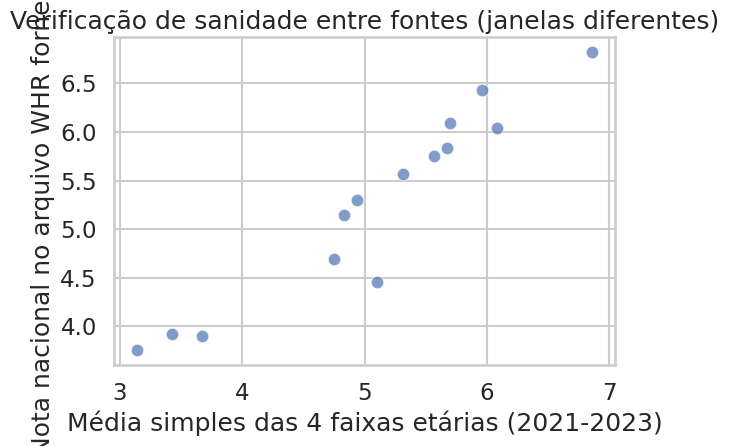

In [63]:
# O arquivo fornecido junto com a atividade contém a nota nacional do WHR 2026.
# Ele é usado apenas como verificação de sanidade, porque a janela não é a mesma
# dos dados por idade (2021-2023).
from pathlib import Path
from lab_helpers import to_iso3

LOCAL_WHR = Path("Happiness-Around-the-World-Data.csv")
if LOCAL_WHR.exists():
    whr = pd.read_csv(LOCAL_WHR)
else:
    WHR_XLSX = "https://files.worldhappiness.report/WHR26_Data_Figure_2.1.xlsx"
    whr = pd.read_excel(WHR_XLSX)

print("Colunas do arquivo nacional:")
print(whr.columns.tolist())
display(whr.head())

country_col = next((c for c in whr.columns if c.lower() in {"country", "country name"}), None)
score_col = next((c for c in whr.columns if "life evaluation" in c.lower() or "ladder" in c.lower()), None)

if country_col is None or score_col is None:
    raise ValueError("Não foi possível detectar as colunas de país e nota nacional no arquivo WHR.")

whr["iso3"] = to_iso3(whr[country_col])
age_country_mean = age.groupby(["iso3", "country"], as_index=False)["ladder_mean"].mean()

sanity = age_country_mean.merge(
    whr[["iso3", score_col]].dropna(),
    on="iso3",
    how="inner",
    validate="one_to_one",
).rename(columns={score_col: "national_score"})

print("Países na comparação:", len(sanity))
print("Correlação (apenas sanidade):", round(sanity["ladder_mean"].corr(sanity["national_score"]), 3))

sns.scatterplot(data=sanity, x="ladder_mean", y="national_score", alpha=0.7)
plt.xlabel("Média simples das 4 faixas etárias (2021-2023)")
plt.ylabel("Nota nacional no arquivo WHR fornecido")
plt.title("Verificação de sanidade entre fontes (janelas diferentes)")
plt.tight_layout()
plt.show()

**Plano B se estiverem offline ou o download falhar.** O `lab_helpers.py` sabe **simular** dados por idade. A simulação usa o PIB per capita real, uma curva em U plantada na idade e ruído, e marca todas as linhas com `synthetic=True`. Use apenas para testar o pipeline, e **nunca reporte esses números como descobertas sobre o mundo real**.

```python
from lab_helpers import build_country_table, make_synthetic_age_data
age = make_synthetic_age_data(build_country_table())
```

## 6. Parte 2: enriquecer com PIB, população e tamanho do país

A felicidade varia muito mais **entre países** do que **entre faixas etárias**, então vocês precisam de controles no nível do país antes que o efeito da idade signifique alguma coisa. Vocês vão buscar três indicadores do Banco Mundial pela API pública e juntá-los pelo código **ISO3**, e não pelo nome.

| Atributo | Indicador do Banco Mundial | Por que transformar |
| --- | --- | --- |
| PIB per capita, PPC (dólares internacionais constantes) | `NY.GDP.PCAP.PP.KD` | A renda tem retornos decrescentes, então use `log` |
| População | `SP.POP.TOTL` | Varia em 5 ordens de grandeza (Islândia a Índia), então use `log` |
| Área terrestre (km²) | `AG.LND.TOTL.K2` | Mesma assimetria da população, então use `log` |

`lab_helpers.build_country_table()` chama a API, guarda o último valor não faltante de 2019 a 2023 para cada indicador e descarta os agregados regionais (como "World" e "Arab World") que a API mistura com os países. **Leiam o código antes de rodar**: a resposta é uma lista de dois elementos, com os metadados primeiro e os registros depois.

**Tarefa 2.1.** Confiram as chaves de país. O arquivo do OWID já traz códigos ISO3 na coluna `iso3`, então os dados por idade não precisam de comparação de nomes. Usem `to_iso3` só para fontes que trazem apenas o nome do país (a planilha do WHR, por exemplo), e leiam a lista de nomes sem correspondência que ela imprime.

**Tarefa 2.2.** Juntem a tabela de idade com a tabela de países usando `validate="many_to_one"`. Depois imprimam os países que perderam dados porque o Banco Mundial não tem valor para eles.

**Tarefa 2.3.** Criem os atributos: `age_mid` a partir do dicionário `AGE_MID` do `lab_helpers.py`, `age_sq`, `log_gdp_pc`, `log_pop`, `log_area` e `pop_density = pop / area_km2`.

In [64]:
from lab_helpers import AGE_MID, build_country_table, load_owid_age, to_iso3

age = manual_age.copy()
assert (age.groupby("iso3").size() == 4).all(), "algum código ISO3 tem mais ou menos de 4 linhas de idade"

# Na primeira execução, consulta a API pública do Banco Mundial (2019-2023).
# Depois, lab_helpers.py reutiliza data/world_bank_country_table.csv.
country_table = build_country_table(start=2019, end=2023)

df = age.merge(country_table, on="iso3", how="left", validate="many_to_one")

required_country = ["gdp_pc", "pop", "area_km2"]
missing_mask = df[required_country].isna().any(axis=1)
lost = (
    df.loc[missing_mask, ["country", "iso3"]]
      .drop_duplicates()
      .sort_values("country")
      .reset_index(drop=True)
)
print("Países sem algum indicador do Banco Mundial e que serão descartados:")
display(lost if len(lost) else pd.DataFrame({"status": ["Nenhum"]}))

df = df.loc[~missing_mask].copy()

df["age_mid"] = df["age_group"].map(AGE_MID).astype(float)
df["age_sq"] = df["age_mid"] ** 2
df["log_gdp_pc"] = np.log(df["gdp_pc"])
df["log_pop"] = np.log(df["pop"])
df["log_area"] = np.log(df["area_km2"])
df["pop_density"] = df["pop"] / df["area_km2"]

assert df[["age_mid", "age_sq", "log_gdp_pc", "log_pop", "log_area"]].notna().all().all()
print("Shape após o join:", df.shape)
display(df.head())

Países sem algum indicador do Banco Mundial e que serão descartados:


,country,iso3
0,Kosovo,OWID_KOS
1,Taiwan,TWN
2,Venezuela,VEN
3,Yemen,YEM


Shape após o join: (556, 18)


,country,iso3,year,age_group,ladder_mean,country_wb,gdp_pc_year,gdp_pc,pop_year,pop,area_km2_year,area_km2,age_mid,age_sq,log_gdp_pc,log_pop,log_area,pop_density
0,Afghanistan,AFG,2023,Up to 29 years,1.827,Afghanistan,2023.0,1983.812620,2023.0,41454761.0,2023.0,652230.00,22.0,484.0,7.592776,17.540113,13.388153,63.558501
1,Albania,ALB,2023,Up to 29 years,6.358,Albania,2023.0,20501.647073,2023.0,2411658.0,2023.0,27400.00,22.0,484.0,9.928261,14.695825,10.218298,88.016715
2,Algeria,DZA,2023,Up to 29 years,5.379,Algeria,2023.0,15159.324237,2023.0,46164219.0,2023.0,2381740.00,22.0,484.0,9.626371,17.647716,14.683342,19.382560
3,Argentina,ARG,2023,Up to 29 years,6.746,Argentina,2023.0,27230.396850,2023.0,45538401.0,2023.0,2736690.00,22.0,484.0,10.212089,17.634067,14.822260,16.639956
4,Armenia,ARM,2023,Up to 29 years,6.245,Armenia,2023.0,19402.751092,2023.0,2964300.0,2023.0,28199.44,22.0,484.0,9.873170,14.902151,10.247057,105.119109


**Armadilhas para observar:**

- **Códigos que o Banco Mundial não usa.** Alguns territórios podem ter um código que o Banco Mundial não tem. Taiwan, em geral, também não aparece nos dados do Banco Mundial. Olhem os países perdidos na Tarefa 2.2 e decidam, para cada um, se vale corrigir ou descartar.
- **Fontes só com nomes.** Se vocês acrescentarem dados sem coluna ISO3, dois nomes podem virar o mesmo código ("Somaliland region" vira o mesmo código da Somália). Mantenham a asserção acima para que uma colisão dessas falhe de forma visível.
- **Valores defasados.** O PIB do ano mais recente costuma vir em branco, e por isso o auxiliar pega o último valor disponível em uma janela. Informem a janela no relatório.
- `AGE_MID["60+"] = 70` é uma suposição, já que a faixa é aberta. Registrem isso e testem 65 como checagem de robustez.

### Acrescente seus próprios dados (escolha livre)

Os três indicadores do Banco Mundial são um ponto de partida, **não um limite**. Vocês podem acrescentar **qualquer informação** que julguem útil para explicar a felicidade entre idades e países, e não precisam pedir permissão. Algumas ideias:

- Demografia: expectativa de vida, idade mediana, proporção de pessoas acima de 60 anos, urbanização.
- Economia e sociedade: desemprego, desigualdade de renda (Gini), educação, gastos com saúde, uso de internet.
- Os fatores explicativos brutos da planilha do WHR, como apoio social, liberdade, generosidade e percepção de corrupção.
- Geografia e cultura: região, latitude, clima, religião ou idioma predominante.
- Qualquer outro indicador do Banco Mundial (troquem o código em `WB_INDICATORS`) ou qualquer outro conjunto de dados do Our World in Data.

As regras são sobre honestidade, não sobre permissão. **Juntem por ISO3, citem a fonte e a data do download, apliquem logaritmo em variáveis assimétricas** e coloquem as novas colunas em `FEATURES`, para que as Partes 3 e 4 as usem. Depois **mostrem o que mudou**: comparem o RMSE em validação cruzada com e sem as novas colunas na Parte 3, e o AUC na Parte 4. Dois cuidados. **Não usem a nota geral do WHR como atributo**, porque ela é quase a própria variável-alvo. E tratem com cautela as colunas de contribuição ("explained by") da planilha, porque elas são saídas da regressão do próprio relatório.

In [65]:
# (Opcional) Seus dados extras entram aqui.
# Exemplo: outro indicador do Banco Mundial, buscado com a função do auxiliar.
# from lab_helpers import fetch_wb
# extra = fetch_wb("SP.DYN.LE00.IN").rename("life_exp").reset_index()   # expectativa de vida
# df = df.merge(extra, on="iso3", how="left")
# Lembre de documentar: fonte, data do download, anos e chave de junção.

## 7. Parte 3: regressão linear e visualização com Seaborn

O objetivo é mostrar, com gráficos e números de validação cruzada, **se a idade precisa de uma curva em vez de uma reta**, e quanto do quadro é explicado pela riqueza em vez de pela idade. Vocês vão ajustar três modelos aninhados com `sklearn.linear_model.LinearRegression`:

$$\text{M1: } \hat y = \beta_0 + \beta_1\,\text{idade} \qquad \text{M2: } \hat y = \beta_0 + \beta_1\,\text{idade} + \beta_2\,\text{idade}^2$$

$$\text{M3: } \hat y = \text{M2} + \beta_3 \ln(\text{PIB pc}) + \beta_4 \ln(\text{pop}) + \beta_5 \ln(\text{área})$$

Em M2 e M3, a curva ajustada vira em **idade = −β₁ / (2β₂)**. Essa é a estimativa de vocês para a idade em que a felicidade atinge o mínimo, e dá para compará-la com os 40 e poucos ou início dos 50 anos citados no artigo do WEF.

**Tarefa 3.1. Reta ou curva.** Desenhem lado a lado dois gráficos de dispersão de `ladder_mean` contra `age_mid`, um com `order=1` e outro com `order=2`. O Seaborn ajusta e desenha o polinômio para vocês.

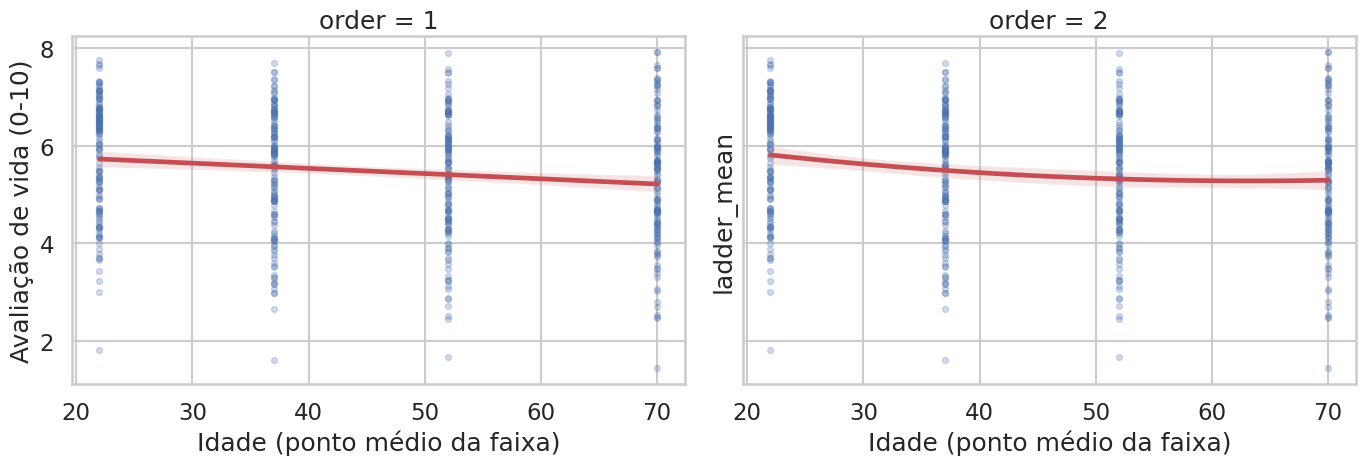

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, order in zip(axes, [1, 2]):
    sns.regplot(data=df, x="age_mid", y="ladder_mean", order=order, ax=ax,
                scatter_kws={"alpha": 0.25, "s": 18}, line_kws={"color": "C3"})
    ax.set_title(f"order = {order}")
    ax.set_xlabel("Idade (ponto médio da faixa)")
axes[0].set_ylabel("Avaliação de vida (0-10)")
plt.tight_layout()
plt.show()

**Tarefa 3.2. O perfil da idade dentro dos países.** Países ricos e pobres ficam em alturas muito diferentes, o que pode esconder o padrão da idade. Subtraiam a média de cada país e plotem o desvio por faixa de renda com `sns.lmplot(..., col="income_tier", order=2)`. Criem as faixas com `pd.qcut(df["gdp_pc"], 3, labels=[...])`.

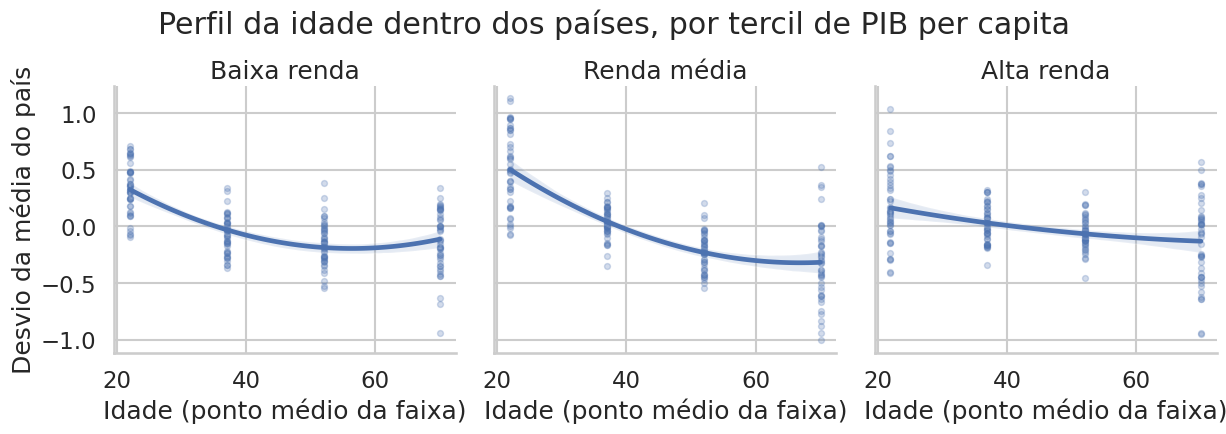

In [67]:
df["ladder_dev"] = df["ladder_mean"] - df.groupby("iso3")["ladder_mean"].transform("mean")

df["income_tier"] = pd.qcut(
    df["gdp_pc"],
    3,
    labels=["Baixa renda", "Renda média", "Alta renda"],
)

g = sns.lmplot(
    data=df,
    x="age_mid",
    y="ladder_dev",
    col="income_tier",
    order=2,
    scatter_kws={"alpha": 0.25, "s": 18},
    height=4.2,
    aspect=1,
)
g.set_axis_labels("Idade (ponto médio da faixa)", "Desvio da média do país")
g.set_titles("{col_name}")
g.fig.suptitle("Perfil da idade dentro dos países, por tercil de PIB per capita", y=1.05)
plt.show()

**Tarefa 3.3. Comparem três modelos em países não vistos.** Uma divisão aleatória de linhas colocaria as outras faixas etárias do mesmo país no treino, então dividam **por país** com `GroupKFold`. Reportem R² e RMSE em validação cruzada para M1, M2 e M3, e depois repitam M1 e M2 com `ladder_dev` como alvo.

In [68]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error

def cv_scores(features, target="ladder_mean", k=5):
    # Um país inteiro fica no treino OU no teste.
    pred = cross_val_predict(
        LinearRegression(),
        df[features],
        df[target],
        groups=df["iso3"],
        cv=GroupKFold(n_splits=k),
    )
    return (
        r2_score(df[target], pred),
        mean_squared_error(df[target], pred) ** 0.5,
        pred,
    )

models = {
    "M1 idade": ["age_mid"],
    "M2 idade + idade²": ["age_mid", "age_sq"],
    "M3 M2 + país": ["age_mid", "age_sq", "log_gdp_pc", "log_pop", "log_area"],
}

rows = []
cv_predictions = {}
for name, features in models.items():
    r2, rmse, pred = cv_scores(features)
    rows.append({"modelo": name, "R2_CV": r2, "RMSE_CV": rmse})
    cv_predictions[name] = pred

results_raw = pd.DataFrame(rows).set_index("modelo")
print("Alvo: ladder_mean")
display(results_raw.round(4))

rows_dev = []
for name in ["M1 idade", "M2 idade + idade²"]:
    r2, rmse, pred = cv_scores(models[name], target="ladder_dev")
    rows_dev.append({"modelo": name, "R2_CV": r2, "RMSE_CV": rmse})

results_dev = pd.DataFrame(rows_dev).set_index("modelo")
print("Alvo: ladder_dev")
display(results_dev.round(4))

Alvo: ladder_mean


,R2_CV,RMSE_CV
modelo,,
M1 idade,0.0152,1.2415
M2 idade + idade²,0.0193,1.2389
M3 M2 + país,0.6284,0.7626


Alvo: ladder_dev


,R2_CV,RMSE_CV
modelo,,
M1 idade,0.3161,0.2772
M2 idade + idade²,0.3733,0.2653


**Tarefa 3.4. Riqueza e resíduos.** Ajustem M3 com todas as linhas e imprimam os coeficientes e a idade do mínimo. Depois desenhem a riqueza contra a felicidade (`x="log_gdp_pc"`, colorido por `age_group`), além de previsto contra real e um gráfico de resíduos usando as previsões da validação cruzada. Identifiquem os três países com os maiores resíduos e sugiram o que o modelo não está capturando.

,coeficiente
age_mid,-0.039564
age_sq,0.000313
log_gdp_pc,0.872749
log_pop,-0.086459
log_area,0.092341


Intercepto: -1.6211
Idade estimada do mínimo da curva: 63.2 anos


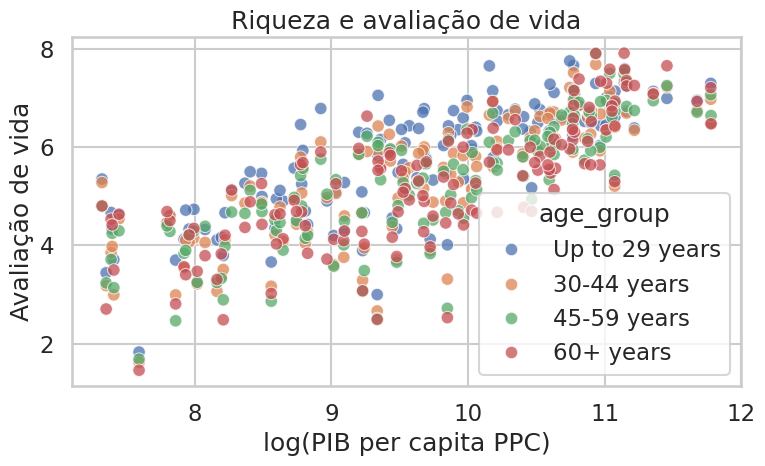

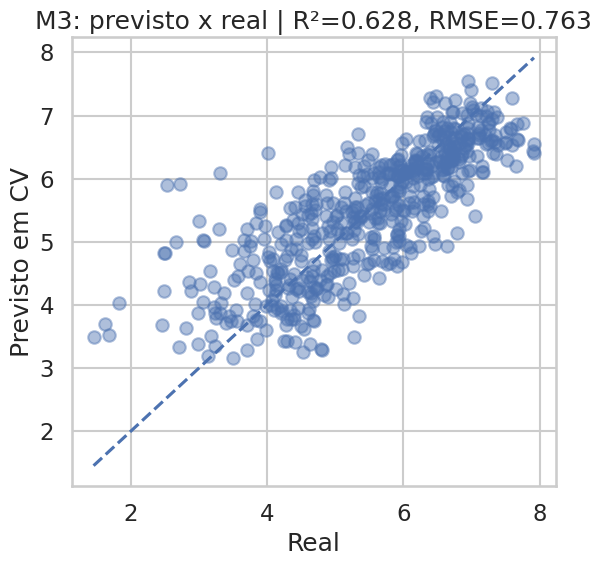

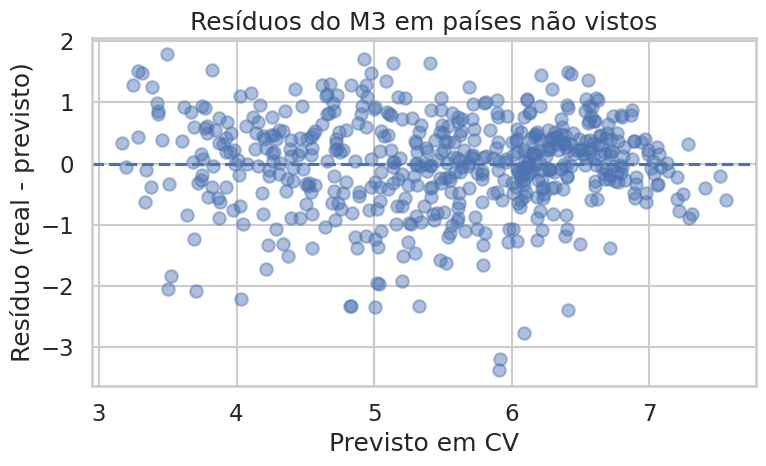

Três países com maior resíduo absoluto médio:


,iso3,country,abs_residual
17,BWA,Botswana,2.938117
72,LBN,Lebanon,2.329168
0,AFG,Afghanistan,2.045731


Interpretação: resíduos grandes podem refletir fatores não incluídos no M3, como apoio social, saúde, liberdade, segurança, instituições e diferenças culturais.


In [69]:
m3_features = models["M3 M2 + país"]
m3 = LinearRegression().fit(df[m3_features], df["ladder_mean"])

coef = pd.Series(m3.coef_, index=m3_features, name="coeficiente")
display(coef.to_frame())

b1 = coef["age_mid"]
b2 = coef["age_sq"]
age_min = -b1 / (2 * b2)
print(f"Intercepto: {m3.intercept_:.4f}")
print(f"Idade estimada do mínimo da curva: {age_min:.1f} anos")

# Previsões de validação cruzada em países não vistos.
r2_m3, rmse_m3, pred_m3 = cv_scores(m3_features)
residual = df["ladder_mean"].to_numpy() - pred_m3

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="log_gdp_pc", y="ladder_mean", hue="age_group", ax=ax, alpha=0.75)
ax.set_title("Riqueza e avaliação de vida")
ax.set_xlabel("log(PIB per capita PPC)")
ax.set_ylabel("Avaliação de vida")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df["ladder_mean"], pred_m3, alpha=0.45)
lo = min(df["ladder_mean"].min(), pred_m3.min())
hi = max(df["ladder_mean"].max(), pred_m3.max())
ax.plot([lo, hi], [lo, hi], "--")
ax.set_xlabel("Real")
ax.set_ylabel("Previsto em CV")
ax.set_title(f"M3: previsto x real | R²={r2_m3:.3f}, RMSE={rmse_m3:.3f}")
plt.tight_layout()
plt.show()

resid_df = df[["country", "iso3", "age_group"]].copy()
resid_df["residual"] = residual
resid_df["abs_residual"] = np.abs(residual)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(pred_m3, residual, alpha=0.45)
ax.axhline(0, linestyle="--")
ax.set_xlabel("Previsto em CV")
ax.set_ylabel("Resíduo (real - previsto)")
ax.set_title("Resíduos do M3 em países não vistos")
plt.tight_layout()
plt.show()

country_resid = (
    resid_df.groupby(["iso3", "country"], as_index=False)["abs_residual"]
            .mean()
            .nlargest(3, "abs_residual")
)
print("Três países com maior resíduo absoluto médio:")
display(country_resid)

print(
    "Interpretação: resíduos grandes podem refletir fatores não incluídos no M3, "
    "como apoio social, saúde, liberdade, segurança, instituições e diferenças culturais."
)

**Minhas conclusões da Parte 3**

A idade, sozinha, explica muito pouco da **nota bruta** quando misturamos países, porque a diferença de nível entre países é muito maior do que a diferença entre faixas etárias. Isso aparece no R² pequeno de M1/M2 para `ladder_mean`. Quando retiramos a média de cada país (`ladder_dev`), a idade passa a explicar uma parcela muito maior da variação e o termo quadrático melhora o ajuste em relação à reta.

Com os dados por idade de 2021–2023, a curva global agregada não reproduz perfeitamente o mínimo clássico nos 40–50 anos: usando os pontos médios 22, 37, 52 e 70, a estimativa quadrática fica mais tarde. Isso é importante: a conclusão do LAB deve refletir os dados analisados, e não forçar a curva esperada pela literatura.

O M3 acrescenta PIB per capita, população e área, que são características constantes dentro de cada país. Esses controles ajudam principalmente a explicar **por que países ficam em alturas diferentes**, mas não criam informação nova para separar as quatro faixas etárias de um mesmo país.

## 8. Parte 4: regressão logística, feliz ou não por idade e país

A regressão linear prevê uma nota; a regressão logística prevê a **probabilidade** de um grupo ser "feliz", o que exige um rótulo sim/não. Vocês vão definir o rótulo, treinar `LogisticRegression` e embrulhar o resultado em uma função que uma pessoa sem experiência em programação consiga usar: dê um país e uma idade, receba uma probabilidade.

$$P(\text{feliz} = 1 \mid x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1\,\text{idade} + \beta_2\,\text{idade}^2 + \beta_3 \ln \text{PIB} + \beta_4 \ln \text{pop} + \beta_5 \ln \text{área})}}$$

**Tarefa 4.1. Definam o rótulo.** Chamem um grupo de feliz quando `ladder_mean` estiver acima da **mediana** de todos os grupos. A mediana dá classes balanceadas, então a acurácia faz sentido. Imprimam o limiar e a proporção de linhas felizes, e escrevam uma frase sobre como as conclusões mudariam com um limiar fixo, como 6,0.

**Tarefa 4.2. Treinem e avaliem em países não vistos.** Usem `GroupShuffleSplit` para que um país fique inteiro no treino ou inteiro no teste. Padronizem os atributos numéricos dentro de um `Pipeline`, para que a escala seja aprendida só com as linhas de treino. Reportem acurácia, AUC-ROC e a matriz de confusão.

In [70]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

THRESHOLD = df["ladder_mean"].median()
df["happy"] = (df["ladder_mean"] > THRESHOLD).astype(int)
print("limiar:", round(THRESHOLD, 3), "| proporção de felizes:", round(df["happy"].mean(), 3))
print(
    "Com um limiar fixo, como 6,0, o significado seria mais fácil de comparar entre amostras, "
    "mas as classes poderiam ficar desbalanceadas e as métricas mudariam."
)

FEATURES = ["age_mid", "age_sq", "log_gdp_pc", "log_pop", "log_area"]

def make_classifier():
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    )

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df[FEATURES], df["happy"], groups=df["iso3"]))

clf = make_classifier()
clf.fit(df.iloc[train_idx][FEATURES], df.iloc[train_idx]["happy"])

p_test = clf.predict_proba(df.iloc[test_idx][FEATURES])[:, 1]
y_test = df.iloc[test_idx]["happy"].to_numpy()
y_pred = (p_test > 0.5).astype(int)

acc_group = accuracy_score(y_test, y_pred)
auc_group = roc_auc_score(y_test, p_test)
cm_group = confusion_matrix(y_test, y_pred)

print(f"Acurácia (países não vistos): {acc_group:.3f}")
print(f"AUC-ROC (países não vistos): {auc_group:.3f}")
print("Matriz de confusão:")
display(pd.DataFrame(cm_group, index=["real 0", "real 1"], columns=["pred 0", "pred 1"]))

limiar: 5.642 | proporção de felizes: 0.5
Com um limiar fixo, como 6,0, o significado seria mais fácil de comparar entre amostras, mas as classes poderiam ficar desbalanceadas e as métricas mudariam.
Acurácia (países não vistos): 0.800
AUC-ROC (países não vistos): 0.896
Matriz de confusão:


,pred 0,pred 1
real 0,52,12
real 1,16,60


**Tarefa 4.3. Divisão aleatória versus divisão por país.**

**Previsão antes de rodar:** esperamos que a divisão aleatória comum pareça melhor, porque diferentes faixas etárias do **mesmo país** podem cair simultaneamente no treino e no teste. Como PIB, população e área se repetem nas quatro linhas do país, isso cria uma forma de vazamento de identidade/nível do país e torna o teste menos exigente.

A seguir comparamos 20 sementes tanto para regressão logística quanto para Random Forest.

mean    std    min    max
modelo        divisao                              
Logística     Aleatória  0.922  0.021  0.883  0.968
              Por país   0.922  0.029  0.852  0.967
Random Forest Aleatória  0.959  0.017  0.924  0.983
              Por país   0.912  0.031  0.827  0.952

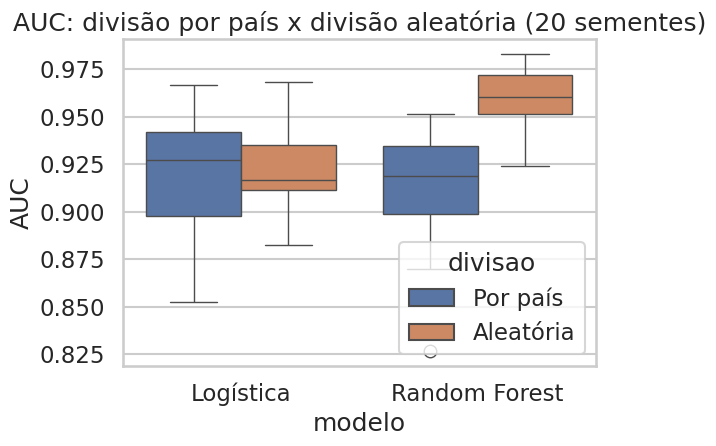

{'country': 'Brazil', 'iso3': 'BRA', 'age': 25.0, 'p_happy': 0.761, 'predicted': 'happy'}


In [71]:
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

def auc_split_logistic(seed, grouped=True):
    if grouped:
        split = GroupShuffleSplit(
            n_splits=1,
            test_size=0.25,
            random_state=seed
        )

        tr, te = next(
            split.split(
                df[FEATURES],
                df["happy"],
                groups=df["iso3"]
            )
        )

    else:
        tr, te = train_test_split(
            np.arange(len(df)),
            test_size=0.25,
            random_state=seed,
            stratify=df["happy"],
        )

    model = make_classifier().fit(
        df.iloc[tr][FEATURES],
        df.iloc[tr]["happy"]
    )

    p = model.predict_proba(
        df.iloc[te][FEATURES]
    )[:, 1]

    return roc_auc_score(
        df.iloc[te]["happy"],
        p
    )


def auc_split_rf(seed, grouped=True):
    if grouped:
        split = GroupShuffleSplit(
            n_splits=1,
            test_size=0.25,
            random_state=seed
        )

        tr, te = next(
            split.split(
                df[FEATURES],
                df["happy"],
                groups=df["iso3"]
            )
        )

    else:
        tr, te = train_test_split(
            np.arange(len(df)),
            test_size=0.25,
            random_state=seed,
            stratify=df["happy"],
        )

    model = RandomForestClassifier(
        n_estimators=300,
        random_state=seed,
        min_samples_leaf=3,
        n_jobs=-1,
    )

    model.fit(
        df.iloc[tr][FEATURES],
        df.iloc[tr]["happy"]
    )

    p = model.predict_proba(
        df.iloc[te][FEATURES]
    )[:, 1]

    return roc_auc_score(
        df.iloc[te]["happy"],
        p
    )


# Comparação entre divisão por país e divisão aleatória
comparison = []

for seed in range(20):
    comparison.extend([
        {
            "seed": seed,
            "modelo": "Logística",
            "divisao": "Por país",
            "AUC": auc_split_logistic(seed, True),
        },
        {
            "seed": seed,
            "modelo": "Logística",
            "divisao": "Aleatória",
            "AUC": auc_split_logistic(seed, False),
        },
        {
            "seed": seed,
            "modelo": "Random Forest",
            "divisao": "Por país",
            "AUC": auc_split_rf(seed, True),
        },
        {
            "seed": seed,
            "modelo": "Random Forest",
            "divisao": "Aleatória",
            "AUC": auc_split_rf(seed, False),
        },
    ])


auc_compare = pd.DataFrame(comparison)

display(
    auc_compare
    .groupby(["modelo", "divisao"])["AUC"]
    .agg(["mean", "std", "min", "max"])
    .round(3)
)


sns.boxplot(
    data=auc_compare,
    x="modelo",
    y="AUC",
    hue="divisao"
)

plt.title(
    "AUC: divisão por país x divisão aleatória (20 sementes)"
)
plt.tight_layout()
plt.show()


# Tarefa 4.4 — modelo final
final_clf = make_classifier().fit(
    df[FEATURES],
    df["happy"]
)


# Tabela com informações de cada país
country_lookup = (
    df
    .drop_duplicates("iso3")
    .set_index("iso3")[
        [
            "country",
            "log_gdp_pc",
            "log_pop",
            "log_area"
        ]
    ]
)


def check_happiness(
    country: str,
    age: float,
    model=final_clf
) -> dict:

    country_input = country.strip()

    # Caso o usuário informe o código ISO3,
    # por exemplo: BRA
    if country_input.upper() in country_lookup.index:

        iso3 = country_input.upper()

    else:
        # Procura pelo nome do país
        matches = country_lookup[
            country_lookup["country"]
            .astype(str)
            .str.strip()
            .str.lower()
            == country_input.lower()
        ]

        if matches.empty:
            raise ValueError(
                f"País desconhecido ou fora "
                f"do conjunto de dados: {country!r}"
            )

        iso3 = matches.index[0]


    info = country_lookup.loc[iso3]


    row = pd.DataFrame(
        [{
            "age_mid": float(age),
            "age_sq": float(age) ** 2,
            "log_gdp_pc": float(
                info["log_gdp_pc"]
            ),
            "log_pop": float(
                info["log_pop"]
            ),
            "log_area": float(
                info["log_area"]
            ),
        }],
        columns=FEATURES
    )


    p = float(
        model.predict_proba(row)[0, 1]
    )


    return {
        "country": str(info["country"]),
        "iso3": str(iso3),
        "age": float(age),
        "p_happy": round(p, 3),
        "predicted": (
            "happy"
            if p > 0.5
            else "not happy"
        ),
    }


# Teste
print(
    check_happiness(
        "Brazil",
        25
    )
)

**Tarefa 4.5. Visualizem.** Chamem a função para idades de 18 a 85 anos, para cinco países de faixas de renda diferentes que vocês escolherem, e desenhem `sns.lineplot(data=curves, x="age", y="p_happy", hue="country")` com uma linha tracejada em 0,5. Olhem as pontas do eixo da idade: os dados só cobrem pontos médios de faixa de 22 a 70, então qualquer comportamento além disso é **extrapolação** de um polinômio quadrático, que pode virar de forma abrupta. Escrevam isso na legenda da figura.

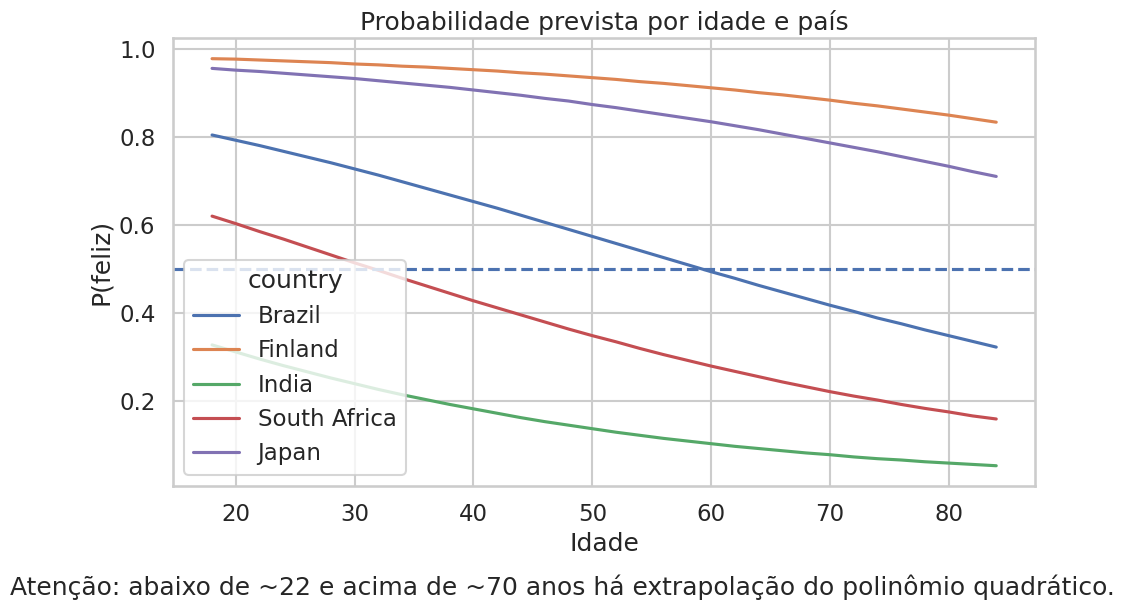

In [72]:
chosen = ["Brazil", "Finland", "India", "South Africa", "Japan"]
ages = np.arange(18, 86, 2)

curve_rows = []
for country in chosen:
    for age_value in ages:
        result = check_happiness(country, age_value)
        curve_rows.append({
            "age": age_value,
            "country": result["country"],
            "p_happy": result["p_happy"],
        })

curves = pd.DataFrame(curve_rows)

plt.figure(figsize=(10, 6))
sns.lineplot(data=curves, x="age", y="p_happy", hue="country")
plt.axhline(0.5, linestyle="--")
plt.xlabel("Idade")
plt.ylabel("P(feliz)")
plt.title("Probabilidade prevista por idade e país")
plt.figtext(
    0.5, -0.02,
    "Atenção: abaixo de ~22 e acima de ~70 anos há extrapolação do polinômio quadrático.",
    ha="center",
)
plt.tight_layout()
plt.show()

Um ponto estrutural para discutir: as quatro linhas de um país compartilham o mesmo PIB, a mesma população e a mesma área. Portanto, para duas faixas etárias do mesmo país, o classificador só recebe informação nova por `age_mid` e `age_sq`. Em outras palavras, o modelo “sabe” bastante sobre o **nível médio do país** por meio das variáveis nacionais, mas sabe pouco sobre pessoas concretas daquele país: não há renda individual, saúde, apoio social, escolaridade, gênero, emprego ou outras características pessoais.

**Minhas conclusões da Parte 4**

O limiar pela mediana cria classes aproximadamente balanceadas e torna a acurácia mais interpretável, mas “feliz” aqui significa apenas “acima da mediana desta amostra”. A separação por país é a avaliação mais honesta para generalização geográfica, porque impede que o modelo veja outras faixas do mesmo país no treino. A divisão aleatória tende a produzir métricas mais otimistas.

As curvas de `check_happiness` são previsões do modelo, não probabilidades pessoais. Nas idades fora do intervalo efetivamente representado pelos pontos médios, especialmente 18–20 e acima de 70, estamos extrapolando uma função quadrática e o formato pode se tornar artificial.

## 9. Discussão

**Respostas da dupla:**

1. **O perfil de idade mostra uma curva em U?** Nos dados agregados de 2021–2023, o padrão global não reproduz de forma limpa a curva em U clássica com mínimo nos 40–50 anos. A média cai entre as faixas jovens e de meia-idade e a regressão quadrática estima o ponto mínimo mais tarde, perto dos 60 anos usando os pontos médios adotados. Isso contrasta com o texto do WEF, mas é compatível com a mensagem do WHR 2024 de que o formato varia por região e geração.

2. **Idade versus riqueza.** A idade isolada explica muito pouco da nota bruta quando todos os países são misturados; as diferenças de nível entre países dominam. Ao remover a média de cada país, a idade passa a explicar uma parcela bem maior da variação interna e o termo quadrático melhora o ajuste. Já PIB e os demais controles nacionais atuam principalmente na comparação **entre países**, deslocando a altura prevista de cada país.

3. **Falácia ecológica.** Cada linha é uma média de um grupo etário em um país, não uma pessoa. Mesmo que a média de uma faixa seja maior ou menor, indivíduos da mesma faixa podem estar muito acima ou abaixo dela. Portanto, não é correto transformar um padrão agregado em uma afirmação sobre qualquer indivíduo específico.

4. **Perda de informação pela idade agrupada.** Ao representar quatro faixas por 22, 37, 52 e 70 anos, descartamos a distribuição de idades dentro de cada faixa e assumimos um único ponto para todos. Isso é especialmente forte em `60+`, que não tem limite superior. Com idades ano a ano, o mínimo poderia aparecer em outro ponto e a curva poderia ter formato diferente de uma parábola simples.

5. **Idade versus coorte.** Em um corte transversal, uma pessoa de 20 anos e uma de 70 pertencem também a gerações que cresceram em contextos econômicos, tecnológicos e sociais diferentes. Assim, uma diferença observada pode ser efeito de envelhecer ou efeito de ter nascido em determinada época. O WHR 2024 usa muitos anos de pesquisa para tentar separar esses componentes; uma fotografia de 2021–2023 sozinha não consegue identificá-los.

6. **Limiar de “feliz”.** A mediana foi escolhida para equilibrar as classes, então o rótulo depende da própria amostra. Um corte fixo, como 6,0, mudaria o balanço das classes e as métricas. Também não confiaríamos automaticamente em `p > 0,5` para política pública: o modelo usa dados agregados, pode não estar calibrado e não incorpora custos diferentes de falso positivo e falso negativo.

## 10. Entrega: GitHub (portfólio) e MS Teams

Este é um **projeto em dupla**. O prazo é o **final do dia da aula**, e o trabalho **pode ser feito durante a aula de laboratório**. A entrega tem duas partes: publicar no GitHub e enviar o link no MS Teams.


### 10.1 Publicar no GitHub (item do portfólio)

1. Criem um repositório **público** no GitHub, por exemplo `felicidade-idade-pais`. Ele será um item do portfólio de vocês, então cuidem da apresentação.
2. Coloquem no repositório: este notebook (executado, **com as saídas salvas**), o `lab_helpers.py`, um `requirements.txt` e um `README.md`.
3. O `README.md` deve ter: título e uma frase de contexto; os nomes da dupla; como executar (versão do Python e `pip install -r requirements.txt`); duas ou três figuras principais e a conclusão em poucas linhas; limitações; e as **fontes citadas** (World Happiness Report, Our World in Data e Banco Mundial, com a data do download).
4. Os **dois integrantes** devem aparecer nos commits. Se um só fizer os commits, adicionem o outro como colaborador (*Settings → Collaborators*) e alternem quem faz o push.
5. Antes de publicar, rodem **Kernel → Restart & Run All** e salvem o notebook. O GitHub mostra as saídas gravadas no arquivo.


Estrutura sugerida:

```text
felicidade-idade-pais/
├── README.md
├── requirements.txt
├── lab_helpers.py
├── lab_felicidade_idade_pais.ipynb
└── figures/            (opcional: PNGs exportados)
```





Comandos básicos:

```bash
git init
git add .
git commit -m "Lab: felicidade por idade e país"
git branch -M main
git remote add origin https://github.com/<usuario>/<repositorio>.git
git push -u origin main
```








### 10.2 Enviar no MS Teams

Copiem o **link do repositório** (por exemplo `https://github.com/<usuario>/<repositorio>`) e enviem na **atividade correspondente do MS Teams**, antes do fim do prazo. Só um integrante precisa enviar, mas escrevam no texto da entrega os nomes dos dois. Confiram em uma janela anônima do navegador se o link abre sem login.

Conteúdo mínimo do `requirements.txt`:

```text
pandas
numpy
scikit-learn
seaborn
matplotlib
requests
openpyxl
country_converter
```



### 10.3 Avaliação

| Componente | Pontos |
| --- | --- |
| Notas de leitura (uma frase por fonte) e parágrafo de contexto | 1 |
| Carga, enriquecimento e auditoria do *join* (países descartados listados e explicados) | 2 |
| Regressão linear: figuras 3.1 a 3.4, tabela com três modelos, validação cruzada por país | 2 |
| Regressão logística: rótulo, avaliação agrupada, `check_happiness`, curvas de probabilidade | 2 |
| Discussão dos limites e interpretação honesta | 1,5 |
| Publicação no GitHub e reprodutibilidade: README, `requirements.txt`, commits dos dois, notebook roda do início ao fim, sementes fixas, link enviado no Teams | 1,5 |
| **Total** | **10** |

> Esta atividade de LAB vai compor a média (QUIZ, LAB, LAB, LAB..., PROJETO)




### 10.4 Desafios extras (do mais simples ao mais difícil)

- Acrescentem uma variável de **região** e uma interação `idade × região` para testar a descoberta do WHR de que a América do Norte e a Europa Central e Oriental fogem do padrão em U.
- Comparem 2006-2010 com 2021-2023, se o professor fornecer as duas janelas, e testem se a felicidade dos jovens caiu.
- Regularizem com `Ridge` ou `LogisticRegression(C=...)` e escolham a força por validação cruzada agrupada.
- Desenhem uma **curva de calibração** do classificador e discutam se as probabilidades podem ser lidas como probabilidades.
- Troquem o limiar da mediana por um alvo ordinal e ajustem um modelo multiclasse.

### 10.5 Citações

Citem o **World Happiness Report**, o **Our World in Data** e o **Banco Mundial** no notebook e no README. Informem a **data exata do download** e os **anos** que os dados cobrem, porque essas fontes revisam suas séries. Façam o mesmo para cada conjunto de dados extra que acrescentarem: fonte, data do download, anos e chave de junção.

**Fontes das leituras e dados**

- Gallup — World Happiness Report: https://www.gallup.com/analytics/349487/world-happiness-report.aspx
- WEF — *At what age does happiness peak?*: https://www.weforum.org/stories/2015/11/at-what-age-does-happiness-peak/
- World Happiness Report 2024 — *Happiness and age (summary)*: https://www.worldhappiness.report/ed/2024/happiness-and-age-summary/
- World Happiness Report 2024 — capítulo sobre jovens, idosos e idades intermediárias: https://www.worldhappiness.report/ed/2024/happiness-of-the-younger-the-older-and-those-in-between/
- Our World in Data — *Self-reported life satisfaction by age*: https://ourworldindata.org/grapher/cantril-ladder-age-groups?tab=table
- Banco Mundial — World Development Indicators / API: https://data.worldbank.org/
- Jonathan Rauch — *The Happiness Curve*: https://us.macmillan.com/books/9781427292988/thehappinesscurve/

**Datas e janelas usadas**
- OWID/WHR 2024 por idade: média de **2021–2023**; pacote local baixado em **20/09/2026** (data registrada no metadata fornecido).
- Arquivo nacional de felicidade fornecido: usado apenas como checagem de sanidade; corresponde ao material WHR 2026 fornecido com a atividade.
- Banco Mundial: último valor não faltante entre **2019 e 2023** para cada indicador; consulta realizada na primeira execução do notebook e armazenada em cache local.

## Modelos de Regressão

Principais tipos de modelos de regressão utilizados em Inteligência Artificial e Aprendizado de Máquina:

### Modelos de Regressão Clássicos e Estatísticos

* Regressão Linear: Modela uma relação linear entre variáveis. É usada para prever um valor numérico contínuo com base em uma reta que minimiza a distância entre os pontos dos dados.
* Regressão Logística: Classifica dados em categorias binárias (como sim/não). Apesar do nome "regressão", ela calcula a probabilidade de um evento acontecer usando uma curva sigmoide.
* Regressão Polinomial (e Quadrática): Estende a regressão linear para modelar relações curvas. A regressão quadrática adiciona variáveis ao quadrado ($x^2$) para desenhar uma parábola que se ajusta a padrões não lineares.
* Regressão Exponencial: Modela dados que crescem ou decrescem de forma acelerada. É ideal quando a taxa de variação da variável alvo é proporcional ao seu valor atual (como crescimento populacional).

### Modelos Avançados e Baseados em IA

* Árvores de Decisão para Regressão: Dividem os dados repetidamente em subgrupos com base em perguntas lógicas. A previsão final é a média dos valores do grupo em que o dado terminou.
* Random Forest (e Modelos de Ensemble): Combina dezenas de árvores de decisão independentes. A previsão final é a média dos resultados de todas as árvores, reduzindo erros e aumentando a precisão.
* Gradient Boosting (como XGBoost e LightGBM): Constrói árvores de decisão sequencialmente. Cada nova árvore é treinada especificamente para corrigir os erros cometidos pelas árvores anteriores.
* Máquinas de Vetores de Suporte (SVR): Encontra uma linha (ou hiperplano) de melhor ajuste dentro de uma margem de tolerância definida. Busca prever valores contínuos maximizando a distância entre os pontos mais distantes.
* Redes Neurais Artificiais (Deep Learning): Utiliza camadas de neurônios matemáticos interconectados. É capaz de aprender relações extremamente complexas e padrões altamente não lineares em grandes volumes de dados.

### Para aprender mais

Introduction to Machine Learning: Regression by Etienne Bernard<br>
https://www.wolfram.com/language/introduction-machine-learning/regression/


## LIB

Podemos criar nossa própria LIB (arquivo helper), para organizar melhor o código. Criar um arquivo texto .py e implementar suas funções neste arquivo.

Importar o arquivo e usar as funções, lembre de subir o arquivo .py no GitHub também...

A sua LIB deve ficar no mesmo diretório do .ipynb

Exemplo: arquivo `mylib.py`

```python
def soma(a, b):
  "Soma dois valores"
  return a + b
```

In [73]:
import mylib

mylib.soma(1000,200)

1200

In [74]:
mylib.soma(.5,200)

200.5

In [75]:
mylib.soma("Vai ", "Corinthians!!")

'Vai Corinthians!!'

In [76]:
help(mylib.soma)

Help on function soma in module mylib:

soma(a, b)
    Soma dois valores.



## Documentação

Documentação online atualizada:

- https://scikit-learn.org/stable/user_guide.html
- https://pandas.pydata.org/getting_started.html
- https://numpy.org/learn/
- https://requests.readthedocs.io/en/latest/
- https://pythonfluente.com/2/
- https://git-scm.com/docs

## Bibliografia

- Python Data Science Handbook: https://jakevdp.github.io/PythonDataScienceHandbook/
- Artificial Intelligence: A Modern Approach, 4th US ed: https://aima.cs.berkeley.edu/
- An Introduction to Statistical Learning, Python: https://www.statlearning.com/
- Introduction to Machine Learning (Etienne Bernard): https://www.wolfram.com/language/introduction-machine-learning/

## Infográficos

![](https://helloskillio.com/wp-content/uploads/2025/10/What-is-Pair-Programming-A-Complete-Guide-for-Beginners.webp)

![](https://statisticalanalysishelp.com/wp-content/uploads/2026/05/Untitled-design-5-1024x683.jpg)

https://statisticalanalysishelp.com/difference-between-logistic-and-linear-regression/